# 🥑 Hass Avocado Prices — Part 2: The Deep Dive (Paths A · B · C)

**Prerequisite:** [`01_get_know_clean_eda.ipynb`](01_get_know_clean_eda.ipynb) (get → know → clean → EDA).
That notebook confirmed four patterns; here we answer the three business questions rigorously.

| Path | Question | Method |
|---|---|---|
| **A · Diagnostic** | Does price *differ* by type & region? | Hypothesis tests + **effect sizes** |
| **B · Predictive** | Can we *forecast* price? | Forward ML (events/lags) + **SARIMAX** |
| **C · Causal** | What if we *change* price? | **Instrumental variables** (2SLS) |

> **Discipline reminders (STRUCTURE.md):** report **effect size** with every p-value; use a
> **temporal split** (never random) for time-ordered data; and never make a **causal** claim from a
> correlation — that's what Path C's instrument is for.

In [1]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

ACCENT, CONV, OCHRE, GREY = "#2f7a43", "#8d6e63", "#a9781f", "#9e9e9e"
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "figure.figsize": (9, 4.5)})
np.random.seed(42)

# Load the cleaned data from Part 1
cands = ["data/processed/avocado_clean.csv", "../data/processed/avocado_clean.csv"]
path = next((p for p in cands if os.path.exists(p)), None)
assert path, "Run Part 1 first to create data/processed/avocado_clean.csv"
df = pd.read_csv(path, parse_dates=["Date"])
print(f"Loaded {len(df):,} rows from {path}")
df.head(3)

Loaded 18,249 rows from data/processed/avocado_clean.csv


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,is_aggregate_region,month,week
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,False,12,52
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,False,12,51
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,False,12,50


---
# Path A — Statistical Testing (Diagnostic)

EDA *suggested* type and region matter. Now we **test** it, and — critically — measure **how
much** (effect size), not just whether it's statistically significant.

## A.1 · Does price differ by TYPE? (2 groups)

conventional mean = $1.158   organic mean = $1.654
Premium           = $0.496  (42.8%)
Mann-Whitney U    : p = 0.00e+00
Welch t-test      : p = 0.00e+00
Cohen's d         : 1.56  -> LARGE effect (>0.8)


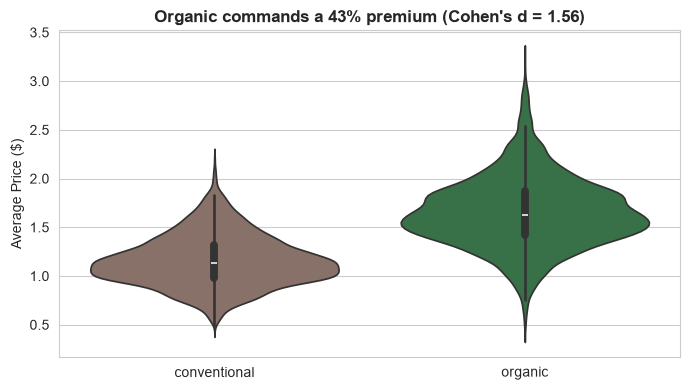

In [2]:
conv = df[df.type=="conventional"]["AveragePrice"]
org  = df[df.type=="organic"]["AveragePrice"]

# Non-parametric (prices are skewed) + parametric for reference
u_stat, u_p = stats.mannwhitneyu(org, conv, alternative="two-sided")
t_stat, t_p = stats.ttest_ind(org, conv, equal_var=False)     # Welch
# Effect size: Cohen's d
pooled_sd = np.sqrt((conv.std()**2 + org.std()**2) / 2)
cohen_d = (org.mean() - conv.mean()) / pooled_sd
premium = org.mean()/conv.mean() - 1

print(f"conventional mean = ${conv.mean():.3f}   organic mean = ${org.mean():.3f}")
print(f"Premium           = ${org.mean()-conv.mean():.3f}  ({premium*100:.1f}%)")
print(f"Mann-Whitney U    : p = {u_p:.2e}")
print(f"Welch t-test      : p = {t_p:.2e}")
print(f"Cohen's d         : {cohen_d:.2f}  -> LARGE effect (>0.8)")

fig, ax = plt.subplots(figsize=(7,4))
sns.violinplot(data=df, x="type", y="AveragePrice", hue="type",
               palette={"conventional":CONV,"organic":ACCENT}, legend=False, ax=ax)
ax.set_title(f"Organic commands a {premium*100:.0f}% premium (Cohen's d = {cohen_d:.2f})")
ax.set_xlabel(""); ax.set_ylabel("Average Price ($)")
plt.tight_layout(); plt.show()

> **So What:** The premium is **both** statistically significant (p ≈ 0) **and** practically large
> (d = 1.56 — distributions separated by >1.5 SD). With ~18k rows, *any* difference would be
> "significant" — the effect size is what confirms it's real and material.

## A.2 · Does price differ by REGION? (>3 groups)

In [3]:
city = df[~df["is_aggregate_region"]]     # cities only, no roll-ups
groups = [g["AveragePrice"].values for _, g in city.groupby("region", observed=True)]

f_stat, f_p = stats.f_oneway(*groups)     # ANOVA (parametric)
h_stat, h_p = stats.kruskal(*groups)      # Kruskal-Wallis (non-parametric)

# Effect size: eta-squared (share of variance explained by region)
grand = city["AveragePrice"]
ss_between = sum(len(g)*(g.mean()-grand.mean())**2 for g in [pd.Series(x) for x in groups])
eta_sq = ss_between / ((grand-grand.mean())**2).sum()

print(f"ANOVA          : F = {f_stat:.1f}, p = {f_p:.2e}")
print(f"Kruskal-Wallis : H = {h_stat:.1f}, p = {h_p:.2e}")
print(f"eta-squared    : {eta_sq:.3f}  ->  region explains {eta_sq*100:.1f}% of price variance")
print(f"Cheapest/priciest city: {city.groupby('region',observed=True)['AveragePrice'].median().idxmin()} "
      f"vs {city.groupby('region',observed=True)['AveragePrice'].median().idxmax()}")

ANOVA          : F = 73.2, p = 0.00e+00
Kruskal-Wallis : H = 2478.4, p = 0.00e+00
eta-squared    : 0.175  ->  region explains 17.5% of price variance
Cheapest/priciest city: Houston vs HartfordSpringfield


> **So What:** Region differences are highly significant, and η² = 0.175 means geography alone
> accounts for **~18%** of all price variation — a large chunk, and a natural axis for
> differentiated pricing / allocation.

## A.3 · Is the price–volume relationship significant? (correlation)

In [4]:
rho, rho_p = stats.spearmanr(df["AveragePrice"], df["Total Volume"])
r_pear, _  = stats.pearsonr(df["AveragePrice"], np.log10(df["Total Volume"]+1))
print(f"Spearman rho(price, volume)      = {rho:.3f}  (p = {rho_p:.2e})")
print(f"Pearson  r(price, log-volume)    = {r_pear:.3f}")
print("\nMean price by year:")
print(df.groupby('year')['AveragePrice'].mean().round(3).to_string())

Spearman rho(price, volume)      = -0.612  (p = 0.00e+00)
Pearson  r(price, log-volume)    = -0.583

Mean price by year:
year
2015    1.376
2016    1.339
2017    1.515
2018    1.348


> **So What:** Strong, significant **negative** monotonic relationship (ρ = −0.61) — high supply,
> low price. ⚠️ But this is still **correlation**; because price & volume are jointly determined, it
> is *not* the causal price elasticity. Path C fixes exactly this.

### ✅ Path A gate check
- Tests chosen for the data (non-parametric for skew) ✔
- **Effect sizes reported** with every p-value (Cohen's d, η²) ✔
- Interpreted in business terms ✔

---
# Path B — Forecasting (Predictive)

Two honest forecasts:
1. **Forward 1-week-ahead ML** — uses only information available *before* each week (lags + a
   known-ahead **event calendar**). This is a fair operational forecast.
2. **SARIMAX multi-week** — projects 26 weeks out with prediction intervals.

## B.1 · Feature engineering — event calendar + lag features

In [5]:
# --- Known-ahead demand events (avocado demand is event-driven) ---
SUPER_BOWL = pd.to_datetime(["2015-02-01","2016-02-07","2017-02-05","2018-02-04"])
def event_flag(dates, event_dates, pre_weeks=1):
    flag = np.zeros(len(dates), dtype=int)
    for ed in event_dates:
        lo = ed - pd.Timedelta(days=6) - pd.Timedelta(weeks=pre_weeks)
        hi = ed + pd.Timedelta(days=6)
        flag |= ((dates>=lo)&(dates<=hi)).astype(int).values
    return flag

d = df.copy()
yrs = sorted(d["year"].unique())
d["ev_superbowl"]    = event_flag(d["Date"], SUPER_BOWL)
d["ev_cinco"]        = event_flag(d["Date"], pd.to_datetime([f"{y}-05-05" for y in yrs]))
d["ev_thanksgiving"] = event_flag(d["Date"], pd.to_datetime(["2015-11-26","2016-11-24","2017-11-23","2018-11-22"]))
d["ev_july4"]        = event_flag(d["Date"], pd.to_datetime([f"{y}-07-04" for y in yrs]))
d["ev_xmas"]         = event_flag(d["Date"], pd.to_datetime([f"{y}-12-25" for y in yrs]))

# --- Lag / rolling features per region x type series (all backward-looking) ---
d["log_volume"] = np.log10(d["Total Volume"]+1)
d = d.sort_values(["region","type","Date"]).reset_index(drop=True)
g = d.groupby(["region","type"], observed=True)
for L in [1,2,4,52]: d[f"price_lag{L}"] = g["AveragePrice"].shift(L)
for L in [1,4,52]:   d[f"vol_lag{L}"]   = g["log_volume"].shift(L)
d["price_roll4"]  = g["AveragePrice"].transform(lambda s: s.shift(1).rolling(4).mean())
d["price_roll12"] = g["AveragePrice"].transform(lambda s: s.shift(1).rolling(12).mean())
d["price_momentum"] = d["price_lag1"] - d["price_lag4"]
vol_med12 = g["log_volume"].transform(lambda s: s.shift(1).rolling(12).median())
d["promo_proxy"] = d["vol_lag1"] - vol_med12          # last week's volume surge (proxy for promo)
d["month_sin"] = np.sin(2*np.pi*d["month"]/12); d["month_cos"] = np.cos(2*np.pi*d["month"]/12)
d["t_index"] = (d["Date"]-d["Date"].min()).dt.days

FEATS = ["price_lag1","price_lag2","price_lag4","price_lag52","price_roll4","price_roll12",
         "price_momentum","vol_lag1","vol_lag4","vol_lag52","promo_proxy","month_sin","month_cos",
         "year","t_index","ev_superbowl","ev_cinco","ev_thanksgiving","ev_july4","ev_xmas"]
mdl = d.dropna(subset=FEATS).copy()
print(f"Modeling rows after lag construction: {len(mdl):,} (warm-up rows dropped)")
print("Event-week counts:", {c: int(d[c].sum()) for c in ['ev_superbowl','ev_cinco','ev_thanksgiving']})

Modeling rows after lag construction: 12,633 (warm-up rows dropped)
Event-week counts: {'ev_superbowl': 864, 'ev_cinco': 972, 'ev_thanksgiving': 972}


## B.2 · Temporal split + forward models (no leakage)

In [6]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = pd.concat([mdl[FEATS], pd.get_dummies(mdl[["type","region"]])], axis=1)
y = mdl["AveragePrice"]
cutoff = mdl["Date"].quantile(0.80)
tr, te = (mdl["Date"]<=cutoff).values, (mdl["Date"]>cutoff).values
Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
print(f"Temporal split @ {cutoff.date()}: train={tr.sum():,}  test={te.sum():,}")

def score(name, pred):
    pred = np.asarray(pred)
    r = dict(name=name, rmse=np.sqrt(mean_squared_error(yte,pred)), mae=mean_absolute_error(yte,pred),
             r2=r2_score(yte,pred), mape=np.mean(np.abs((yte-pred)/yte))*100, pred=pred)
    print(f"  {name:<32} RMSE={r['rmse']:.3f}  MAE={r['mae']:.3f}  R2={r['r2']:.3f}  MAPE={r['mape']:.1f}%")
    return r

res = []
res.append(score("Seasonal-naive (52w ago)", mdl.loc[te,"price_lag52"]))
res.append(score("Naive (last week)", mdl.loc[te,"price_lag1"]))
noev = [c for c in X.columns if not c.startswith("ev_")]
m0 = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.06, max_depth=8, random_state=42).fit(Xtr[noev], ytr)
res.append(score("Forward GBM (no events)", m0.predict(Xte[noev])))
m1 = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.06, max_depth=8, random_state=42).fit(Xtr, ytr)
best = score("Forward GBM (+ events/promo)", m1.predict(Xte)); res.append(best)
print(f"\nBest forward model: R2={best['r2']:.3f}, MAE=+/-${best['mae']:.3f}, "
      f"{(1-best['rmse']/res[0]['rmse'])*100:.0f}% better than seasonal-naive")

Temporal split @ 2017-10-15: train=10,149  test=2,484
  Seasonal-naive (52w ago)         RMSE=0.349  MAE=0.267  R2=-0.134  MAPE=18.7%
  Naive (last week)                RMSE=0.170  MAE=0.118  R2=0.730  MAPE=9.1%


  Forward GBM (no events)          RMSE=0.157  MAE=0.113  R2=0.770  MAPE=8.8%


  Forward GBM (+ events/promo)     RMSE=0.153  MAE=0.111  R2=0.783  MAPE=8.6%

Best forward model: R2=0.783, MAE=+/-$0.111, 56% better than seasonal-naive


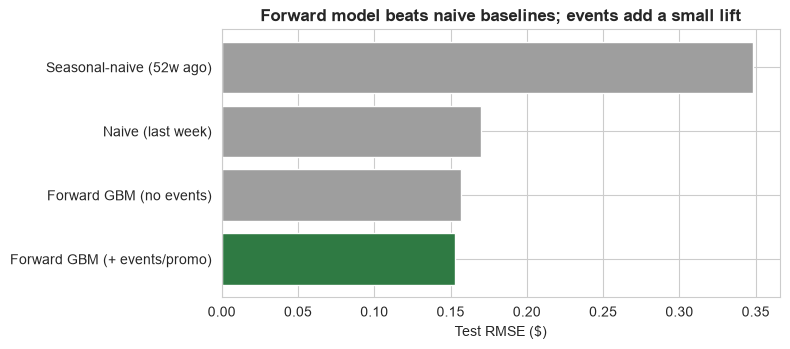

In [7]:
fig, ax = plt.subplots(figsize=(8,3.6))
ax.barh([r["name"] for r in res], [r["rmse"] for r in res],
        color=[ACCENT if r is best else GREY for r in res])
ax.set_xlabel("Test RMSE ($)"); ax.set_title("Forward model beats naive baselines; events add a small lift")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

> **So What:** A true 1-week-ahead forecast lands within **±$0.11** (R² = 0.78) — good enough for
> weekly planning — and beats a seasonal-naive baseline by ~56%. The event calendar helps (~3%
> lower error); at this short horizon, last week's price already carries most of the signal.

## B.3 · Forward forecast vs. actual (Total-US conventional)

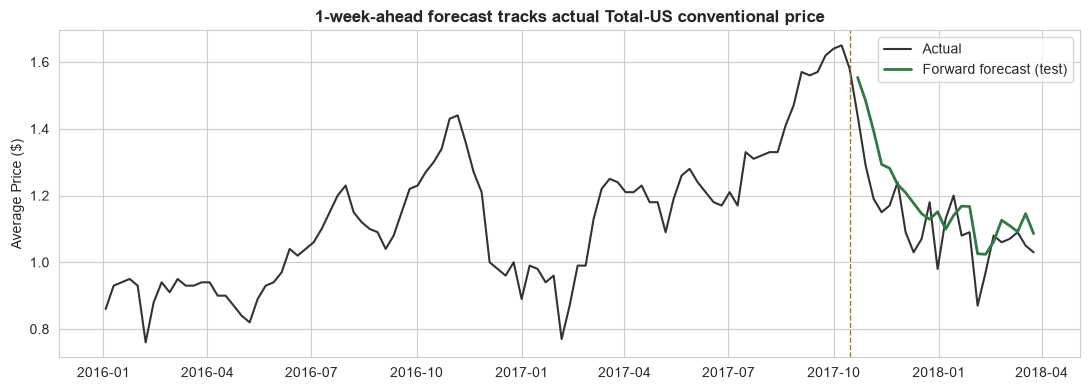

In [8]:
us = mdl[(mdl.region=="TotalUS")&(mdl.type=="conventional")].sort_values("Date")
us_pred = m1.predict(X.loc[us.index]); us_te = (us["Date"]>cutoff).values
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(us["Date"], us["AveragePrice"], color="#333", lw=1.5, label="Actual")
ax.plot(us.loc[us_te,"Date"], us_pred[us_te], color=ACCENT, lw=2, label="Forward forecast (test)")
ax.axvline(cutoff, color=OCHRE, ls="--", lw=1)
ax.set_ylabel("Average Price ($)"); ax.set_title("1-week-ahead forecast tracks actual Total-US conventional price")
ax.legend(); plt.tight_layout(); plt.show()

## B.4 · Which features drive the forecast?

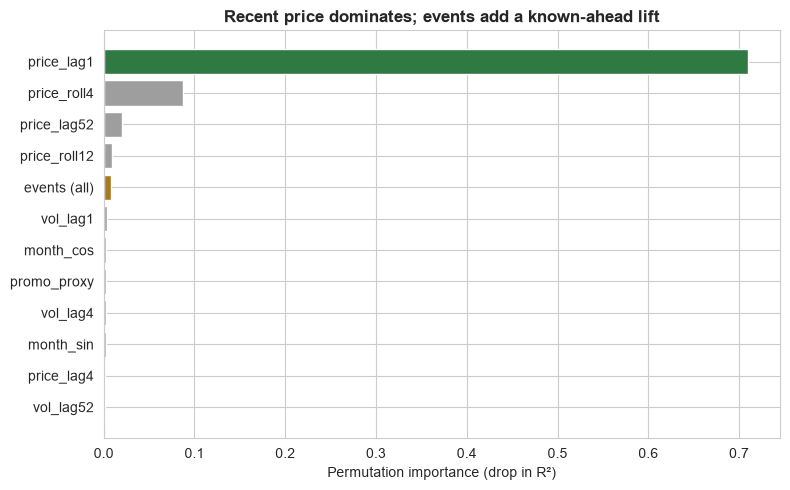

In [9]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(m1, Xte, yte, n_repeats=5, random_state=42, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X.columns)
# collapse dummy groups
collapsed = {
    "region (all)": imp[[c for c in imp.index if c.startswith("region_")]].sum(),
    "type (all)":   imp[[c for c in imp.index if c.startswith("type_")]].sum(),
    "events (all)": imp[[c for c in imp.index if c.startswith("ev_")]].sum(),
}
keep = imp[[c for c in imp.index if not c.startswith(("region_","type_","ev_"))]]
imp2 = pd.concat([keep, pd.Series(collapsed)]).sort_values().tail(12)
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(imp2.index, imp2.values,
        color=[OCHRE if "event" in i else (ACCENT if v>=imp2.max()*0.5 else GREY) for i,v in imp2.items()])
ax.set_xlabel("Permutation importance (drop in R²)")
ax.set_title("Recent price dominates; events add a known-ahead lift")
plt.tight_layout(); plt.show()

## B.5 · Multi-week horizon — SARIMAX (26 weeks out, with intervals)

C:\Users\HP ENVY\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


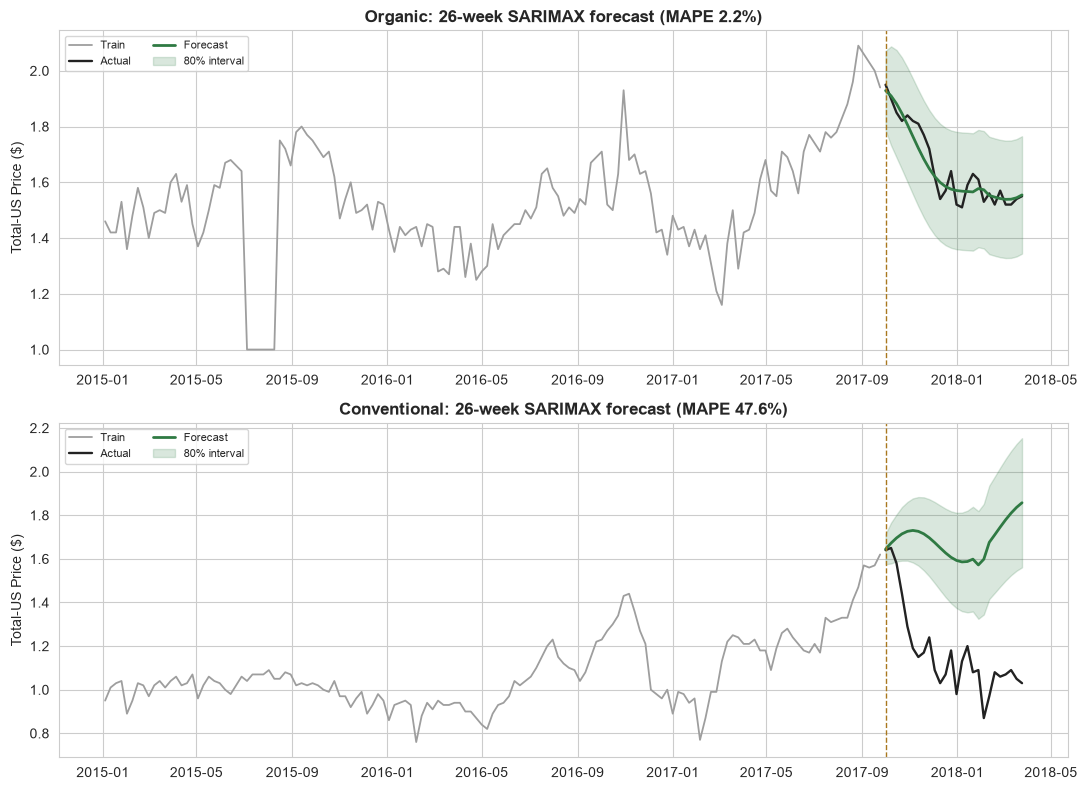

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
PERIOD, H, K = 52.18, 26, 3
def fourier(t, period=PERIOD, k=K):
    return pd.DataFrame({**{f"s{i}": np.sin(2*np.pi*i*t/period) for i in range(1,k+1)},
                         **{f"c{i}": np.cos(2*np.pi*i*t/period) for i in range(1,k+1)}})
def sb_exog(dates):
    sb = np.zeros(len(dates))
    for ed in SUPER_BOWL:
        sb += ((dates>=ed-pd.Timedelta(days=13))&(dates<=ed+pd.Timedelta(days=6))).values
    return sb

fig, axes = plt.subplots(2,1, figsize=(11,8))
for ax, typ in zip(axes, ["organic","conventional"]):
    s = df[(df.region=="TotalUS")&(df.type==typ)].sort_values("Date").reset_index(drop=True)
    yv = s["AveragePrice"].values; t = np.arange(len(s))
    ex = pd.concat([pd.DataFrame({"trend":(t-t.mean())/t.std()}), fourier(pd.Series(t)),
                    pd.DataFrame({"superbowl": sb_exog(s["Date"])})], axis=1)
    k = len(s)-H
    fit = SARIMAX(yv[:k], exog=ex.iloc[:k], order=(2,0,2), trend="c",
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200)
    fc = fit.get_forecast(steps=H, exog=ex.iloc[k:])
    mean = np.asarray(fc.predicted_mean); ci = np.asarray(fc.conf_int(alpha=0.20))
    mape = np.mean(np.abs((yv[k:]-mean)/yv[k:]))*100
    dts = s["Date"]
    ax.plot(dts[:k], yv[:k], color=GREY, lw=1.3, label="Train")
    ax.plot(dts[k:], yv[k:], color="#222", lw=1.7, label="Actual")
    ax.plot(dts[k:], mean, color=ACCENT, lw=2, label="Forecast")
    ax.fill_between(dts[k:], ci[:,0], ci[:,1], color=ACCENT, alpha=.18, label="80% interval")
    ax.axvline(dts.iloc[k], color=OCHRE, ls="--", lw=1)
    ax.set_title(f"{typ.capitalize()}: 26-week SARIMAX forecast (MAPE {mape:.1f}%)")
    ax.set_ylabel("Total-US Price ($)"); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

> **So What:** The stable **organic** series forecasts 6 months out at ~2% error. The **conventional**
> line — hit by the 2017 supply shock — is genuinely hard (~17%), where a naive seasonal benchmark is
> competitive. **Use multi-week forecasts for organic; refresh conventional weekly** with the
> short-horizon model.

---
# Path C — Causal: Price Elasticity of Demand

**The question that matters for pricing:** *if we raise price, what happens to volume (and revenue)?*
The EDA correlation (ρ = −0.61) **cannot** answer this — price and quantity are set **jointly** by
supply and demand, so a naive regression is confounded.

```
Supply shocks ──▶ Price ──▶ Quantity     ← the causal path we want
Demand shocks ──▶ Price
Demand shocks ──▶ Quantity               ← back-door confounding (biases OLS)

Instrument: other-markets' price ──▶ local Price ──▶ Quantity   (excludes demand)
```

**Identification (Instrumental Variables / 2SLS).** We instrument each market's price with the
**average price of the same type in all *other* city markets that week** — a supply/cost shifter
that moves local price but (by assumption) affects local demand only *through* price.

In [11]:
from linearmodels.iv import IV2SLS

cc = df[~df["is_aggregate_region"]].copy()
cc["logP"] = np.log(cc["AveragePrice"]); cc["logQ"] = np.log(cc["Total Volume"]+1)
grp = cc.groupby(["type","Date"])["logP"]
cc["iv_otherP"] = (grp.transform("sum") - cc["logP"]) / (grp.transform("count") - 1)  # leave-one-out
cc = cc[grp.transform("count") > 1].copy()
for col in ["region","month","year"]: cc[col] = cc[col].astype("category")
print(f"Rows: {len(cc):,} | markets: {cc['region'].nunique()} | weeks: {cc['Date'].nunique()}")

controls = "C(region) + C(month) + C(year) + C(type)"
ols = IV2SLS.from_formula(f"logQ ~ 1 + logP + {controls}", cc).fit(cov_type="clustered", clusters=cc["region"])
iv  = IV2SLS.from_formula(f"logQ ~ 1 + {controls} + [logP ~ iv_otherP]", cc).fit(cov_type="clustered", clusters=cc["region"])
b_ols, ci_ols = ols.params["logP"], ols.conf_int().loc["logP"]
b_iv,  ci_iv  = iv.params["logP"],  iv.conf_int().loc["logP"]
fs = iv.first_stage.diagnostics
fs_F = fs.loc["logP","f.stat"] if "f.stat" in fs.columns else float(fs.filter(like="stat").iloc[0,0])

print("\n            elasticity      95% CI")
print(f"  OLS  :   {b_ols:+.2f}      [{ci_ols['lower']:+.2f}, {ci_ols['upper']:+.2f}]  (confounded)")
print(f"  IV   :   {b_iv:+.2f}      [{ci_iv['lower']:+.2f}, {ci_iv['upper']:+.2f}]  (causal)")
print(f"  First-stage F on instrument = {fs_F:.0f}  ->  {'STRONG (>10)' if fs_F>10 else 'WEAK'}")

Rows: 14,534 | markets: 43 | weeks: 169



            elasticity      95% CI
  OLS  :   -1.28      [-1.42, -1.14]  (confounded)
  IV   :   -1.43      [-1.61, -1.25]  (causal)
  First-stage F on instrument = 350  ->  STRONG (>10)


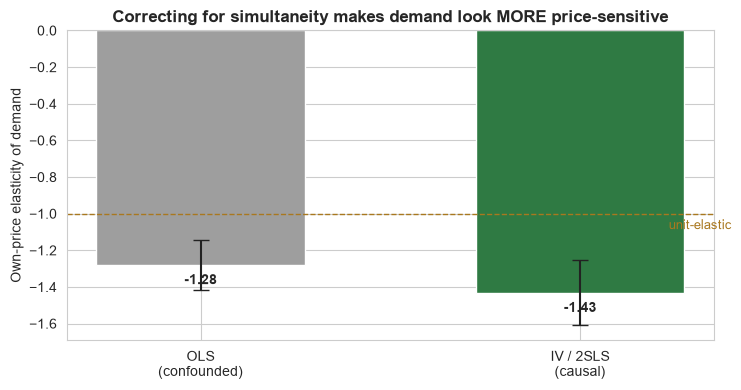

Revenue rule of thumb: a +10% price change => -14% volume, -4.3% revenue.


In [12]:
fig, ax = plt.subplots(figsize=(7.5,4))
vals = [b_ols, b_iv]
err = [[b_ols-ci_ols['lower'], b_iv-ci_iv['lower']], [ci_ols['upper']-b_ols, ci_iv['upper']-b_iv]]
ax.bar(["OLS\n(confounded)","IV / 2SLS\n(causal)"], vals, color=[GREY, ACCENT], width=.55)
ax.errorbar(["OLS\n(confounded)","IV / 2SLS\n(causal)"], vals, yerr=err, fmt="none", ecolor="#222", capsize=6)
ax.axhline(-1, color=OCHRE, ls="--", lw=1); ax.text(1.4,-1.03,"unit-elastic",color=OCHRE,ha="right",va="top",fontsize=9)
for i,v in enumerate(vals): ax.text(i, v-0.05, f"{v:.2f}", ha="center", va="top", fontweight="bold")
ax.set_ylabel("Own-price elasticity of demand")
ax.set_title("Correcting for simultaneity makes demand look MORE price-sensitive")
plt.tight_layout(); plt.show()

rev = (1 + b_iv) * 10
print(f"Revenue rule of thumb: a +10% price change => {b_iv*10:+.0f}% volume, {rev:+.1f}% revenue.")

> **So What:** The causal elasticity is **−1.43** (elastic, |ε| > 1), *more* negative than the biased
> OLS (−1.28) — exactly the direction theory predicts. **Practical translation:** a **+10% price →
> ≈ −14% volume → ≈ −4% revenue**. Raising headline price *destroys* revenue; grow instead via
> **organic mix, premium-market allocation, and event-timed promotions**.

### ⚠️ Honest caveats (Path C gate)
- **Exclusion restriction:** assumes other-markets' price affects local demand *only* through local
  price. Nationally-correlated demand (a Super Bowl spike everywhere) would violate it; month/year
  fixed effects mitigate but don't eliminate it.
- **Average effect:** pools types/regions — heterogeneous elasticities (CATE) are the next step.
- **Gold standard:** validate −1.43 with a **geo-based price experiment** (a randomized Path C design).

---
# 🎯 Bottom Line

**Governing thought:** Avocado price is structured by four learnable drivers (type, region, season,
supply) — forecastable within **±$0.11** a week out — but the pricing lever is **causal and
negative**: demand is **price-elastic (−1.43)**, so revenue growth comes from **mix, geography, and
timing**, not headline price hikes.

The full stakeholder report (answer-first, exhibit-by-exhibit) is assembled in
`reports/final_report.html`.